In [38]:
# Phase-2 — Risk Scoring Engine + Alerts Table

In [39]:
# Step 1 — Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
# Step 2 — Load Clean Transactions Dataset

In [42]:
transactions = pd.read_csv("transactions_clean.csv")

print("Dataset Shape:", transactions.shape)

transactions.head()

Dataset Shape: (6362620, 7)


,Transaction_ID,Customer_ID,Transaction_Hour,type,Amount,Fraud_Label,Transaction_Date
0,1,C1231006815,1,PAYMENT,9839.64,0,2020-01-01 01:00:00
1,2,C1666544295,1,PAYMENT,1864.28,0,2020-01-01 01:00:00
2,3,C1305486145,1,TRANSFER,181.00,1,2020-01-01 01:00:00
3,4,C840083671,1,CASH_OUT,181.00,1,2020-01-01 01:00:00
4,5,C2048537720,1,PAYMENT,11668.14,0,2020-01-01 01:00:00


In [43]:
# Step 3 — Create Rule-Based Risk Signals

In [44]:
# Amount Risk (Normalized)
transactions["Amount_Risk"] = (
    transactions["Amount"] / transactions["Amount"].max()
)

In [45]:
# Transaction Type Risk Fraud mostly occurs in TRANSFER and CASH_OUT
transactions["Type_Risk"] = np.where(
    transactions["type"].isin(["TRANSFER", "CASH_OUT"]),
    1,
    0
)

In [46]:
# Fraud Signal (Simulation Feature)
transactions["Fraud_Signal"] = transactions["Fraud_Label"]

In [47]:
# Step 4 — Compute Risk Score

In [48]:
# Weighted scoring system.

transactions["Risk_Score"] = (
    0.5 * transactions["Amount_Risk"] +
    0.3 * transactions["Type_Risk"] +
    0.2 * transactions["Fraud_Signal"]
)

In [49]:
# Step 5 — Inspect Risk Score Distribution

In [50]:
transactions["Risk_Score"].describe()

,Risk_Score
count,6.362620e+06
mean,1.318568e-01
std,1.499082e-01
min,1.081718e-10
25%,8.093241e-05
50%,1.186609e-03
75%,3.007754e-01
max,8.000000e-01


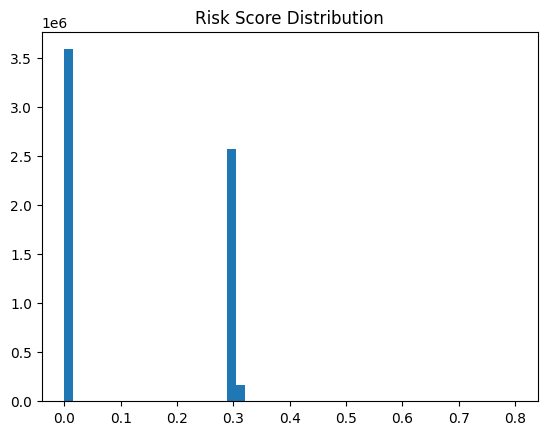

In [51]:
plt.hist(transactions["Risk_Score"], bins=50)
plt.title("Risk Score Distribution")
plt.show()

In [52]:
# Step 6 — Create Risk Tiers

In [53]:
transactions["Risk_Tier"] = pd.cut(
    transactions["Risk_Score"],
    bins=[0, 0.4, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

In [54]:
transactions["Risk_Tier"].value_counts()

,count
Risk_Tier,
Low,6353453
Medium,9166
High,1


In [55]:
# Step 7 — Generate Alerts

In [56]:
# Alerts are generated for Medium + High risk transactions

alerts = transactions[
    transactions["Risk_Tier"] != "Low"
].copy()

print("Alerts Shape:", alerts.shape)

Alerts Shape: (9167, 12)


In [57]:
# Step 8 — Create Alert_ID

In [58]:
alerts["Alert_ID"] = range(1, len(alerts) + 1)

In [59]:
# Step 9 — Add Alert Metadata

In [60]:
alerts["Investigation_Status"] = "Pending"

alerts["Alert_Date"] = alerts["Transaction_Date"]

In [61]:
# Step 10 — Final Alerts Table

In [62]:
alerts = alerts[
[
"Alert_ID",
"Transaction_ID",
"Customer_ID",
"Alert_Date",
"Risk_Score",
"Risk_Tier",
"Investigation_Status"
]
]

In [63]:
alerts.head()

,Alert_ID,Transaction_ID,Customer_ID,Alert_Date,Risk_Score,Risk_Tier,Investigation_Status
2,1,3,C1305486145,2020-01-01 01:00:00,0.500001,Medium,Pending
3,2,4,C840083671,2020-01-01 01:00:00,0.500001,Medium,Pending
251,3,252,C1420196421,2020-01-01 01:00:00,0.500015,Medium,Pending
252,4,253,C2101527076,2020-01-01 01:00:00,0.500015,Medium,Pending
680,5,681,C137533655,2020-01-01 01:00:00,0.500109,Medium,Pending


In [64]:
# Step 11 — Validate Fraud Detection Rate

In [65]:
alerts_fraud_rate = alerts["Transaction_ID"].isin(
    transactions[transactions["Fraud_Label"] == 1]["Transaction_ID"]
).mean()

print("Alert Fraud Rate:", alerts_fraud_rate)

Alert Fraud Rate: 0.8959310570524708


In [66]:
# Step 12 — Alert Volume by Risk Tier

In [67]:
alerts.groupby("Risk_Tier").size()

/tmp/ipykernel_239/2189547945.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  alerts.groupby("Risk_Tier").size()


,0
Risk_Tier,
Low,0
Medium,9166
High,1


In [68]:
# Step 13 — Alert Trend Over Time

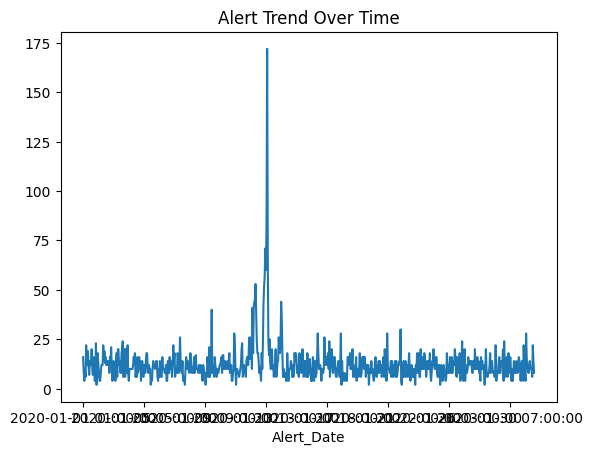

In [69]:
alerts.groupby("Alert_Date").size().plot()

plt.title("Alert Trend Over Time")

plt.show()

In [70]:
# Step 14 — Save Alerts Dataset

In [71]:
alerts.to_csv("alerts_table.csv", index=False)